In [1]:
%%bash
pip install rasterio
pip install pillow
pip install cmweather
wget -nc -q https://nimbus.niu.edu/courses/EAE483/BREF_090508_1300.png
wget -nc -q https://nimbus.niu.edu/courses/EAE483/rgb_imagery.tif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 1.6 MB/s eta 0:00:00


# L10 - Image Filtering

Directions:

1. Please rename the file by clicking on “LX-First-Last.ipynb” where X is the lab number, and replace First and Last with your first and last name.

2. Click File -> Save to make sure your most recent edits are saved.

3. In the upper right hand corner of the screen, click on “Share”. Click on “Restricted” and change it to “Anyone with the link”. Make sure you also share it with `ahaberlie1@gmail.com`.

4. Copy the link and submit it on Blackboard. Make sure you follow these steps completely, or I will be unable to grade your work.

### Overview

This lab will help you understand scikit-image and its basic methods. We will walk through some examples of how scikit-image can help solve Geoscience problems. Periodically, I will 1) ask you to either repeat the demonstrated code in a slightly different way; or 2) ask you to combine two or more techniques to solve a problem.

You can use generative AI to help answer these problems. **The answer should still be in your own words.** Think of the generative AI descriptions as those from a book. You still have to cite your source and you cannot plagiarize directly from the source. For every question that you used generative AI for help, please reference the generative AI you used and what your prompt or prompts were.

However, it is crucial that you understand the code well enough to effectively use generative AI tools that are likely to be widely available and recommended for use at many organizations. Although they are improving at an incredible rate, they still produce bugs, especially with domain-specific and complex problems. Make sure that you verify the answers before putting them in your own words.

### scikit-image

This package, sometimes called ["skimage"](https://scikit-image.org/), provides an interface to many methods for digital image processing. We will work with both RGB (3, y, x) and grayscale images (y, x).

### Problem 1

The following image is provided to you:

(np.float64(-0.5), np.float64(1279.5), np.float64(1023.5), np.float64(-0.5))

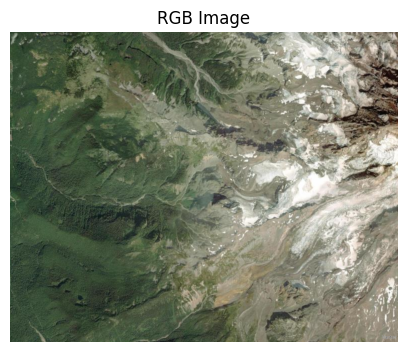

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

tif_path = "rgb_imagery.tif"

with rasterio.open(tif_path) as src:
    arr = src.read()

rgb = np.transpose(arr[:3], (1, 2, 0))
plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.title(f"RGB Image")
plt.axis("off")

You are asked to make it a smaller resolution by using `scipy.ndimage.maximum_filter` to find the max value in a 10x10 region for each channel using the code below.

To make the image look more presentable, they want you to blur the image 50x before plotting it. You must keep the size the same, and the message below will print `False` if this is not the case.

NOTE: You may have to convert your results back to `np.uint8`. This can be done with numpy arrays only as follows:

```
orig_array = orig_array / 5

orig_array = orig_array.astype(np.uint8)
```

If you do not do this, you might not be able to plot the image.

Make sure you set your result to the variable `combine` or it will not plot or check your size correctly.

Do the sizes match? True


(np.float64(-0.5), np.float64(1279.5), np.float64(1023.5), np.float64(-0.5))

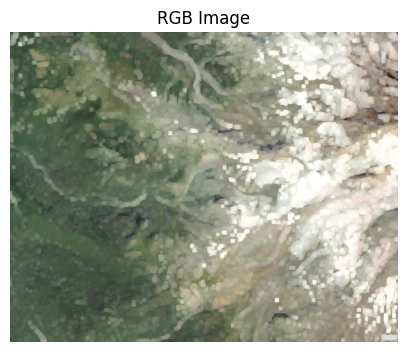

In [3]:
import numpy as np
from scipy.ndimage import maximum_filter
import matplotlib.pyplot as plt

r = rgb[:, :, 0]
g = rgb[:, :, 1]
b = rgb[:, :, 2]

r_max = maximum_filter(r, size=10)
g_max = maximum_filter(g, size=10)
b_max = maximum_filter(b, size=10)

combine = np.stack([r_max, g_max, b_max], axis=2)

size = combine.shape

### insert code here

# combine = your result so it plots below
### insert code here

size_after = combine.shape

print("Do the sizes match?", size == size_after)

plt.figure(figsize=(5, 5))
plt.imshow(combine)
plt.title(f"RGB Image")
plt.axis("off")

### Problem 2

You are given the following image:

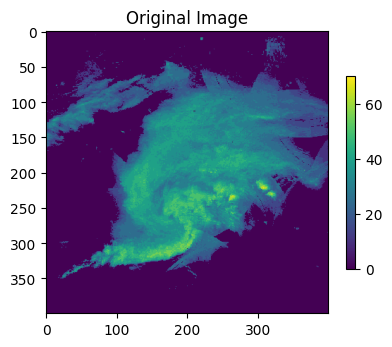

In [4]:
from PIL import Image
plt.rcParams['figure.figsize'] = 10, 10

def read_and_subset_radar_png(filename):
    img = Image.open(filename)
    img = np.array(img)
    img = img[600:1000, 1700:2100]
    img = img * 5

    return img

img = read_and_subset_radar_png("BREF_090508_1300.png")

ax = plt.subplot(1, 2, 1)
ax.set_title("Original Image")
mmp = ax.imshow(img)
plt.colorbar(mmp, ax=ax, shrink=0.25)

You are asked to identify the edges and then sharpen the image. The image should have the same size as before (400, 400) and it should have the same range of values as before (0 - 70)